In [1]:
!pip install datasets sentence-transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.7/472.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.8/255.8 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 18.2 MB/s eta 0:00:00


# Task: Text Clustering with Custom KMeans

Using sentence_transformers, convert a set of texts into embeddings, and apply clustering using a custom implementation of KMeans. The goal is to group similar texts based on different distance metrics (such as cosine similarity, Euclidean distance, or Manhattan distance) implemented in the KMeans algorithm.

## 1. Data loading

Load the GO Emotions dataset from Hugging Face to obtain the texts that will be clustered. If you prefer some other dataset you can use it.

In [2]:
from datasets import load_dataset

dataset = load_dataset('google-research-datasets/go_emotions', split='train')


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/350k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Print some examples

In [3]:
for i in range(5):
    print(f"Text {i+1}: {dataset[i]['text']}")

Text 1: My favourite food is anything I didn't have to cook myself.
Text 2: Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
Text 3: WHY THE FUCK IS BAYLESS ISOING
Text 4: To make her feel threatened
Text 5: Dirty Southern Wankers


## 2. Convert texts to embeddings

Use the sentence-transformers library to transform the texts into embeddings (numerical vectors) for clustering.

In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np

docs = dataset['text']
model = SentenceTransformer('stsb-roberta-large')
embeddings = model.encode(docs, convert_to_tensor=False)
embeddings = np.array(embeddings)

print(f"Shape of embeddings: {embeddings.shape}")


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.96k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


1_Pooling/config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Shape of embeddings: (43410, 1024)


## 3. Implement custom KMeans

Create a custom implementation of KMeans, supporting at leas four different distance metrics (Correlation, Euclidean, Cosine, Mahalanobis). You shouldn't use any specific libs, only numpy.
Here are the formulas for correlation distance and Mahalanobis distance:

#### Correlation Distance
Correlation distance measures the difference in the direction of vectors rather than their magnitude. The formula for correlation distance is:

$$
d_{\text{corr}}(a, b) = 1 - \frac{\sum_{i=1}^{n}(a_i - \bar{a})(b_i - \bar{b})}{\sqrt{\sum_{i=1}^{n}(a_i - \bar{a})^2} \sqrt{\sum_{i=1}^{n}(b_i - \bar{b})^2}}
$$

where:
- $a$ and $b$ are two vectors,
- $\bar{a}$ and $\bar{b}$ are the mean values of the components of vectors $a$ and $b$, respectively.

or using ```np.corrcoef```:

$$
d_{\text{corr}}(a, b) = 1 - np.corrcoef(a, b)[0,1]
$$


#### Mahalanobis Distance
Mahalanobis distance accounts for not only the distance between points but also the covariance between them. The formula is:

$$
d_{\text{mahal}}(a, b) = \sqrt{(a - b)^T S^{-1} (a - b)}
$$

where:
- $a$ and $b$ are two vectors,
- $S$ is the covariance matrix of the features,
- $S^{-1}$ is the inverse covariance matrix.


In [5]:
import numpy as np

def euclidean_distance(a: np.ndarray, b: np.ndarray):
    diff = a - b
    distance = np.sqrt(np.sum(diff ** 2))
    return distance

def manhattan_distance(a: np.ndarray, b: np.ndarray):
    abs_diff = np.abs(a - b)
    distance = np.sum(abs_diff)
    return distance

def cosine_distance(a, b):
    dot_product = np.dot(a, b)

    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    cosine_similarity = dot_product / (norm_a * norm_b)
    cosine_distance = 1 - cosine_similarity
    return cosine_distance

def mahalanobis_distance(a, b, cov_inv):
    delta = a - b
    distance = np.sqrt(np.dot(np.dot(delta, cov_inv), delta))
    return distance

def correlation_distance(a, b):
    mean_a = np.mean(a)
    mean_b = np.mean(b)
    centered_a = a - mean_a
    centered_b = b - mean_b
    numerator = np.sum(centered_a * centered_b)

    denominator = np.sqrt(np.sum(centered_a ** 2) * np.sum(centered_b ** 2))

    correlation = numerator / denominator
    correlation_distance = 1 - correlation

    return correlation_distance

Implement custom K-Means class

In [18]:
import tqdm
class CustomKMeans:
  def __init__(self, n_clusters=3, max_iter=100, distance_metric="euclidean",  **kwargs):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.distance_metric = distance_metric
        self.centroids = None
        self.labels_ = None
        self.kwargs = kwargs # inverted covariation matrix for mahalanodis disntace

  def fit(self, X):
        random_indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for _ in tqdm.tqdm(range(self.max_iter)):
            self.labels_ = np.array([self._assign_label(x) for x in (X)])

            new_centroids = np.array([X[self.labels_ == i].mean(axis=0) if len(X[self.labels_ == i]) > 0 else self.centroids[i] for i in range(self.n_clusters)])

            if np.all(self.centroids == new_centroids):
                break
            self.centroids = new_centroids

  def _assign_label(self, x):
        distances = []
        for centroid in self.centroids:
            if self.distance_metric == 'euclidean':
                distances.append(euclidean_distance(x, centroid))

            elif self.distance_metric == 'manhattan':
                distances.append(manhattan_distance(x, centroid))

            elif self.distance_metric == 'cosine':
                distances.append(cosine_distance(x, centroid))

            elif self.distance_metric == 'mahalanobis':
                cov_inv = self.kwargs.get('cov_inv', None)
                if cov_inv is None:
                    raise ValueError("Для метрики 'mahalanobis' необходимо передать обратную ковариационную матрицу через параметр 'cov_inv'.")
                distances.append(mahalanobis_distance(x, centroid, cov_inv))

            elif self.distance_metric == 'correlation':
                distances.append(correlation_distance(x, centroid))

            else:
                raise ValueError(f"Неизвестная метрика расстояния: {self.distance_metric}")

        return np.argmin(distances)

## 4. Fit the custom K-Means

In [7]:
embeddings

array([[-1.9180385 ,  1.0391711 , -0.9470414 , ...,  0.87688345,
        -1.3040452 ,  0.09339865],
       [-1.2686523 ,  0.9314456 ,  0.99711275, ..., -0.08294479,
        -0.6660811 ,  1.0559309 ],
       [-0.88117254,  1.0079124 ,  0.12723625, ..., -0.96302384,
        -1.1919298 ,  0.13841668],
       ...,
       [-1.0696111 ,  0.41324043, -0.15490568, ...,  0.53452134,
        -1.7004339 ,  0.1978191 ],
       [ 0.47888383,  0.73727113, -0.557478  , ...,  0.43381423,
        -0.15826207,  0.89492935],
       [-0.34275994,  1.0396385 , -1.0655552 , ...,  0.36913544,
        -1.0333555 , -0.00199389]], dtype=float32)

Fit the custom KMeans model to the dataset using all of the distance metrics and obtain cluster labels.

In [19]:
n_clusters = 10
cov_matrix = np.cov(embeddings, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

custom_kmeans = CustomKMeans(n_clusters=10,   distance_metric='euclidean', cov_inv=inv_cov_matrix)
custom_kmeans.fit(embeddings)

labels = custom_kmeans.labels_

print("Custom KMeans labels for the first 10 texts:")
print(labels[:10])


100%|██████████| 100/100 [06:03<00:00,  3.63s/it]

Custom KMeans labels for the first 10 texts:
[1 3 9 8 3 3 6 6 3 9]


## 5. Visualize the results

Visualize the clusters by reducing the dimensionality of the embeddings using PCA and plotting the clusters in 2D space.  
You should get something like this:

<a href="https://ibb.co/nRY9hQf"><img src="https://i.ibb.co/zNBpKPb/output.png" alt="output" border="0"></a>

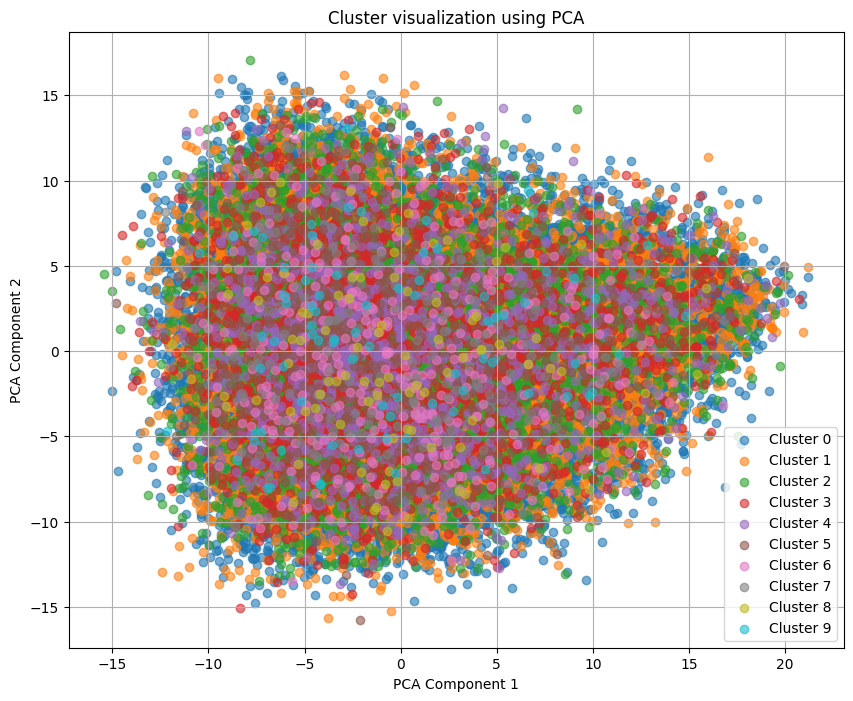

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters(X, labels):
    X = np.array(X)

    pca = PCA(n_components=2)
    X_reduced = pca.fit_transform(X)
    num_clusters = len(np.unique(labels))

    plt.figure(figsize=(10, 8))

    for cluster in range(num_clusters):
        cluster_points = X_reduced[labels == cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}', alpha=0.6)

    plt.title('Cluster visualization using PCA')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_clusters(embeddings, labels)

Let's print examples of the text for each cluster

In [20]:
for cluster in range(n_clusters):
    print(f"\nCluster {cluster}:")
    cluster_texts = [docs[i] for i in range(len(docs)) if labels[i] == cluster]
    for text in cluster_texts[:5]:
        print(f"- {text}")


Cluster 0:
- Thank you friend
- I miss them being alive
- Super, thanks
- Happy to be able to help.
- aw, thanks! I appreciate that! 

Cluster 1:
- My favourite food is anything I didn't have to cook myself.
- Your aunt has some damn nerve, though!
- Famous for his 3-4 Defense
- When I feel down I listen to music.
- LOL. Super cute!

Cluster 2:
- Hello everyone. Im from Toronto as well. Can call and visit in personal if needed.
- You are going to do the dishes now
- Mine was apparently [NAME] and the giant peach!
- I know. My question was if they **used** to compete in T5-TTT2.
- FBI!! OPEN UP!!!

Cluster 3:
- Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
- Dirty Southern Wankers
- OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.
- Damn youtube and outrage drama is super lucrative for reddit
- Aww... she'll probably come around eventually, I'm sure she was just jealous 

## 6. Report

Make a conclusion and write a short report. What are the differnes between the methods used? What are their limitations? What is the applicability of each?

# Графики кластеров

## Euclidean
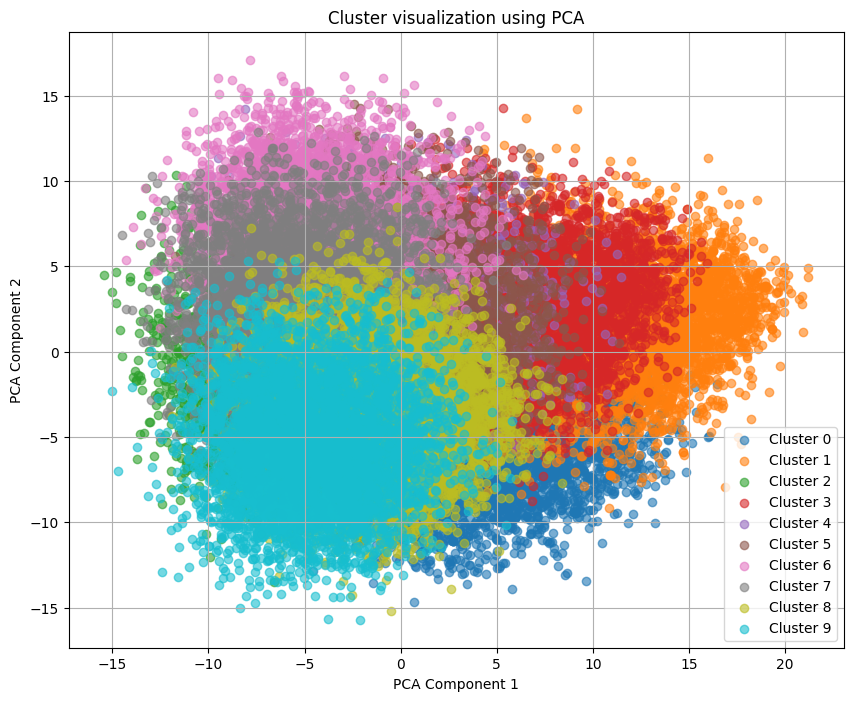

## Manhattan
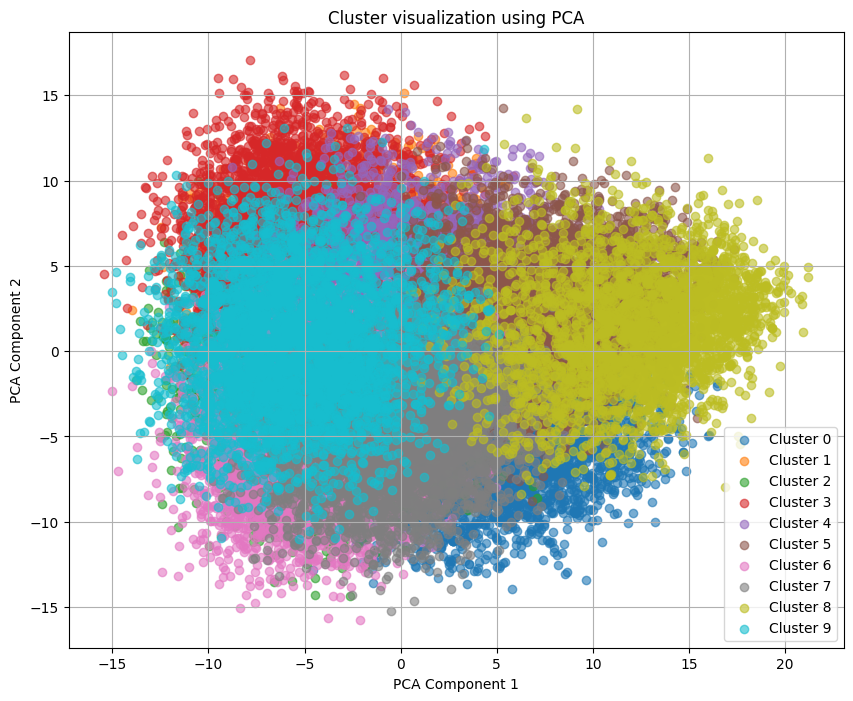

## Cosine
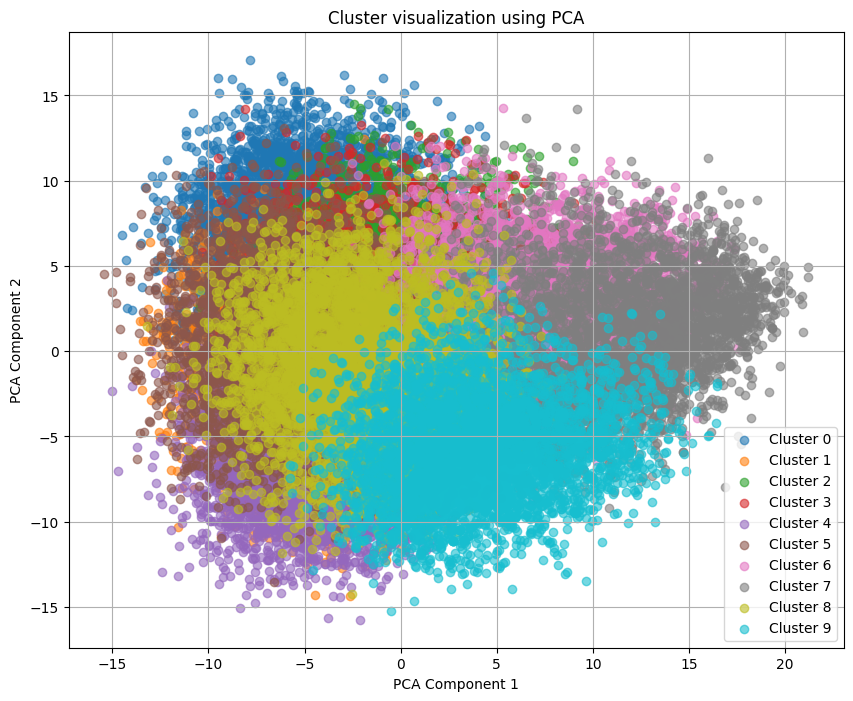

## Mahalanobis
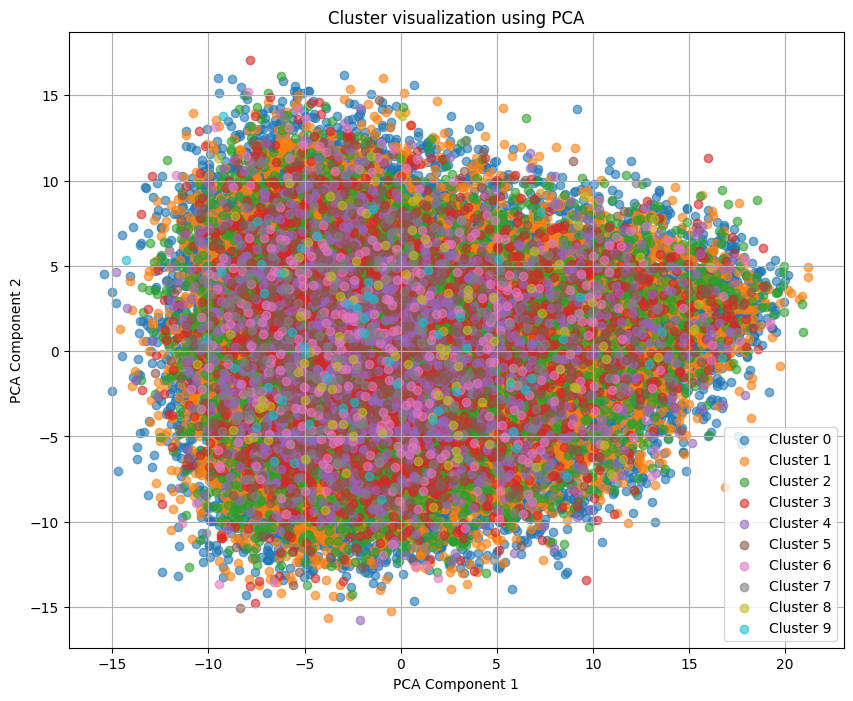

## Correlation
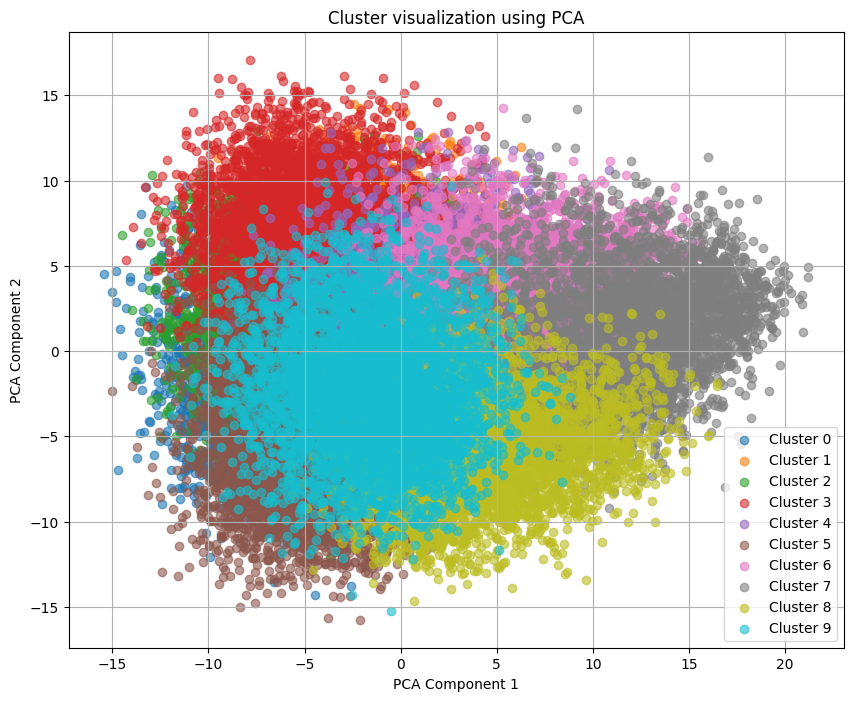

1. **В первом пункте были представлены графики**
2. **Результаты по метрикам**
   
   **2.1. Косинусное расстояние**
   - **Особенности кластеров**: Группы основаны на тематическом и стилистическом сходстве, так как косинусное расстояние акцентирует внимание на схожести угла между векторами.
   - **Основные выводы**:
     - Кластеры четко различимы по тональности: выделены дружелюбные группы, группы с агрессивным тоном и группы, ориентированные на обсуждение фактов.
     - Легче всего было выделить кластеры с позитивными и поддерживающими комментариями.
     - Косинусное расстояние хорошо группирует данные по тематике, независимо от длины текстов.
   - **Преимущества и недостатки**:
     - Подходит для кластеризации по эмоциональной и стилистической тональности.
     - Менее эффективен для определения структурных паттернов, поскольку не учитывает частотные различия между словами.

   **2.2. Манхэттенское расстояние**
   - **Особенности кластеров**: Группировка акцентирует внимание на частотах и интенсивности использования слов.
   - **Основные выводы**:
     - Данная метрика выделила кластеры по темам и эмоциям, которые зависят от конкретных выражений.
     - Замечено, что выделяются кластеры, объединенные грубыми и саркастичными фразами, что может быть полезным для анализа негатива.
     - Присутствуют кластеры с более легкими и позитивными сообщениями, но структура получается менее четкой.
   - **Преимущества и недостатки**:
     - Подходит для группировки по эмоциональным паттернам и частоте ключевых фраз.
     - Может быть менее точен в группировке текстов по разной длине, поскольку на короткие тексты оказывает сильное влияние вес слов.

   **2.3. Расстояние Махаланобиса**
   - **Особенности кластеров**: Акцент на корреляциях между элементами данных, что помогает сгруппировать более тонкие связи и скрытые тематические ассоциации.
   - **Основные выводы**:
     - Данный метод выделил более разнородные кластеры с акцентом на глубокие связи, такие как серьезные обсуждения, эмоциональные выражения и личные комментарии.
     - Подходит для кластеров, которые имеют сложные внутренние паттерны и тематики, которые могут пересекаться.
     - Хорошо справляется с выделением различных оттенков эмоций, таких как самокритика, поддержка и грубость.
   - **Преимущества и недостатки**:
     - Подходит для детального анализа сложных тем и эмоциональных оттенков в текстах.
     - Сложнее интерпретировать результаты, так как кластеры могут выглядеть разнородными и перекрывающимися.

   **2.4. Корреляционное расстояние**
   - **Особенности кластеров**: Группировка основана на связях и схожести в формах и распределении слов, что помогает объединить тексты с одинаковым стилем.
   - **Основные выводы**:
     - Полученные кластеры отражают общий эмоциональный тон (позитивный, негативный, саркастичный).
     - Выделяются группы, содержащие выражение недовольства или грубости, а также группы с поддержкой и благодарностью.
     - Метод показал хороший результат при объединении текстов со схожим стилем или тоном, даже при разных лексических составах.
   - **Преимущества и недостатки**:
     - Подходит для анализа тональности и стиля текста.
     - Менее эффективен в идентификации конкретных тем, так как акцент делает на общие шаблоны использования слов.

  **2.5. Евклидово расстояние**
   - **Особенности кластеров**: Данная метрика сгруппировала фразы, опираясь на лексическое сходство и близость структурных характеристик.
   - **Основные выводы**:
     - Евклидово расстояние выделило кластеры с четким различием по стилю и тону. Например, Cluster 0 включает позитивные выражения с благодарностью и признательностью, тогда как Cluster 8 и Cluster 3 содержат грубые и саркастичные высказывания.
     - Кластеры, полученные по Евклидову расстоянию, в значительной степени зависят от частотности и длины сообщений, что делает их менее универсальными для коротких текстов.
     - Тексты с эмоциональной окраской легко группируются, что позволяет выделить четкие кластеры для разных настроений (позитивные комментарии, сарказм, грубость).
   - **Преимущества и недостатки**:
     - Преимущество метода заключается в том, что он интуитивно группирует схожие по лексике фразы и выявляет конкретные тональные группы, такие как поддержка, агрессия или нейтральные высказывания.
     - Ограничение метода в том, что Евклидово расстояние может быть менее эффективным для текстов с разной длиной и сложностью, так как оно не учитывает корреляцию между словами или скрытые смысловые связи.


3. **Сравнительный анализ**
   - **Тематика и эмоциональная тональность**: Косинусное и корреляционное расстояния лучше всего подходят для кластеризации по тону и стилю (позитив/негатив), а манхэттенское и расстояние Махаланобиса — для более специфических тематических и эмоциональных паттернов.
   - **Грубость и сарказм**: Манхэттенское расстояние и расстояние Махаланобиса лучше идентифицируют негативные и саркастичные группы, особенно для коротких, резких высказываний.
   - **Поддержка и позитив**: Косинусное и корреляционное расстояния выделили кластеры с благодарностью и позитивом более явно.
   - **Сложность тем и глубина анализа**: Расстояние Махаланобиса позволило создать более детализированные кластеры для сложных и многослойных тем, где пересекаются различные эмоции и отношения.

4. **Вывод**
   - Для анализа **тональности** и **эмоционального окраса** сообщений: лучше использовать косинусное или корреляционное расстояния.
   - Для анализа **структуры** и **специфических выражений** (например, грубых и саркастичных высказываний): манхэттенское расстояние и расстояние Махаланобиса.
   - Для анализа **комплексных тем и глубины текста**: предпочтительно использовать расстояние Махаланобиса, так как оно учитывает корреляции и выявляет скрытые зависимости между элементами текста.
   - Евклидово расстояние эффективно для базового анализа тональности и структурного сходства